### importation des bibliotheques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import OrdinalEncoder


### import du jeu de donnée

In [2]:
data=pd.read_csv("../data/data.csv",sep=";")

### infos general du data set

In [3]:
data.shape

(4424, 37)

In [4]:
data.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
data.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

 aucune valeur nulle

In [7]:
data[data.duplicated()]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target


variable cible non encodé donc encodons la

In [8]:
mapping=[{'col':'Target',
          'mapping':{
              'Dropout':1,
              'Graduate':0,
              'Enrolled':2
          }
          }]
enc=OrdinalEncoder(mapping=mapping)
Target=enc.fit_transform(data.Target)
data.Target=Target
data=data.loc[data['Target']!=2,:]

distribution du Target

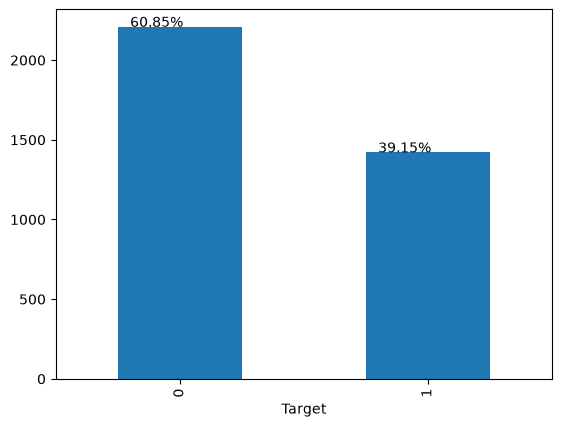

In [9]:
data['Target'].value_counts().plot(kind='bar')
for index,temp in enumerate(data['Target'].value_counts()):
    plt.text(index-0.2,temp,f"{round((temp/data.shape[0])*100,2)}%")

Aucun doublon

In [10]:
numerical=['Previous qualification (grade)','Admission grade','Age at enrollment','Curricular units 1st sem (credited)','Curricular units 1st sem (enrolled)','Curricular units 1st sem (evaluations)','Curricular units 1st sem (approved)','Curricular units 1st sem (grade)','Curricular units 1st sem (without evaluations)','Curricular units 2nd sem (enrolled)','Curricular units 2nd sem (evaluations)','Curricular units 2nd sem (grade)','Curricular units 2nd sem (without evaluations)','Unemployment rate','Inflation rate','GDP']

In [11]:
data[numerical].describe()

,Previous qualification (grade),Admission grade,Age at enrollment,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,132.920606,127.293939,23.461157,0.754270,6.337466,8.071074,4.791460,10.534860,0.128926,6.296419,7.763085,10.036155,0.142149,11.630358,1.231598,-0.009256
std,13.238373,14.611295,7.827994,2.477277,2.570773,4.286632,3.237845,5.057694,0.679111,2.263020,3.964163,5.481742,0.747670,2.667652,1.384911,2.259986
min,95.000000,95.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,125.000000,118.000000,19.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,5.000000,6.000000,10.517857,0.000000,9.400000,0.300000,-1.700000
50%,133.100000,126.500000,20.000000,0.000000,6.000000,8.000000,5.000000,12.341429,0.000000,6.000000,8.000000,12.333333,0.000000,11.100000,1.400000,0.320000
75%,140.000000,135.100000,25.000000,0.000000,7.000000,10.000000,6.000000,13.500000,0.000000,7.000000,10.000000,13.500000,0.000000,13.900000,2.600000,1.790000
max,190.000000,190.000000,70.000000,20.000000,26.000000,45.000000,26.000000,18.875000,12.000000,23.000000,33.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [12]:
data['Curricular units 1st sem (grade)']

0        0.000000
1       14.000000
2        0.000000
3       13.428571
4       12.333333
          ...    
4419    13.600000
4420    12.000000
4421    14.912500
4422    13.800000
4423    11.666667
Name: Curricular units 1st sem (grade), Length: 3630, dtype: float64

(array([ 647.,    0.,    0.,    0.,    0.,  376., 1480.,  977.,  139.,
          11.]),
 array([ 0.    ,  1.8875,  3.775 ,  5.6625,  7.55  ,  9.4375, 11.325 ,
        13.2125, 15.1   , 16.9875, 18.875 ]),
 <BarContainer object of 10 artists>)

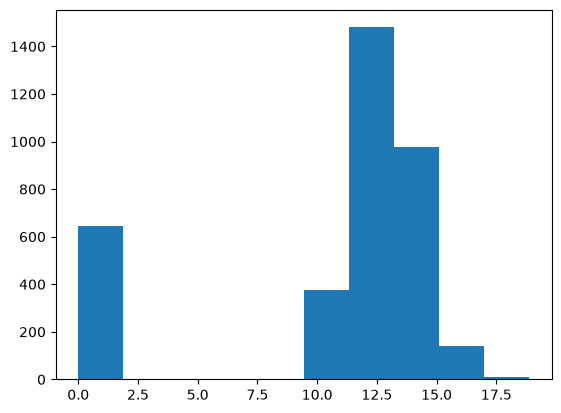

In [13]:
plt.hist(data['Curricular units 1st sem (grade)'])

In [14]:
data.loc[data['Curricular units 1st sem (grade)']<3]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,1
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.0,0,15.5,2.8,-4.06,1
12,1,1,2,9853,1,1,133.0,1,19,37,...,0,6,0,0,0.0,0,12.7,3.7,-1.70,1
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0,0.0,0,11.1,0.6,2.02,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4368,1,39,1,9991,0,1,120.0,1,37,37,...,0,5,5,0,0.0,0,9.4,-0.8,-3.12,1
4370,1,1,3,171,1,1,137.0,1,1,3,...,0,0,0,0,0.0,0,12.7,3.7,-1.70,0
4372,1,39,1,9003,1,1,130.0,1,12,12,...,0,6,10,0,0.0,0,12.4,0.5,1.79,1
4375,1,43,1,9991,0,1,161.0,1,37,37,...,0,5,5,0,0.0,0,7.6,2.6,0.32,1


In [15]:
soupcon=data.loc[data['Curricular units 1st sem (grade)']<3,["Curricular units 1st sem (credited)","Curricular units 1st sem (enrolled)","Curricular units 1st sem (evaluations)","Curricular units 1st sem (approved)","Curricular units 1st sem (grade)","Target"]]
soupcon

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
0,0,0,0,0,0.0,1
2,0,6,0,0,0.0,1
7,0,5,5,0,0.0,1
12,0,6,6,0,0.0,1
20,0,0,0,0,0.0,0
...,...,...,...,...,...,...
4368,0,5,5,0,0.0,1
4370,0,0,0,0,0.0,0
4372,0,6,7,0,0.0,1
4375,0,5,5,0,0.0,1


In [16]:
soupcon['Target'].value_counts()/soupcon.shape[0]

Target
1    0.880989
0    0.119011
Name: count, dtype: float64

In [17]:
soupcon1=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]==0) & (soupcon["Curricular units 1st sem (evaluations)"]==0)]
soupcon1

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
0,0,0,0,0,0.0,1
20,0,0,0,0,0.0,0
66,0,0,0,0,0.0,0
72,0,0,0,0,0.0,1
101,0,0,0,0,0.0,0
...,...,...,...,...,...,...
4308,0,0,0,0,0.0,1
4331,0,0,0,0,0.0,1
4353,0,0,0,0,0.0,0
4365,0,0,0,0,0.0,0


In [18]:
soupcon1.shape[0]

152

In [19]:
soupcon1["Target"].value_counts()/soupcon1.shape[0]

Target
1    0.506579
0    0.493421
Name: count, dtype: float64

In [20]:
soupcon2=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]==0) & (soupcon["Curricular units 1st sem (evaluations)"]>0)]
soupcon2

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target


In [21]:
soupcon3=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]>0) & (soupcon["Curricular units 1st sem (evaluations)"]==0)]
soupcon3

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
2,0,6,0,0,0.0,1
36,0,5,0,0,0.0,1
44,0,5,0,0,0.0,1
102,0,6,0,0,0.0,1
104,0,6,0,0,0.0,1
...,...,...,...,...,...,...
4145,0,6,0,0,0.0,1
4181,0,6,0,0,0.0,1
4327,0,5,0,0,0.0,1
4330,0,6,0,0,0.0,1


In [22]:
soupcon3['Target'].value_counts()/soupcon3.shape[0]

Target
1    1.0
Name: count, dtype: float64

In [23]:
soupcon3.shape[0]

169

In [24]:
soupcon4=soupcon.loc[(soupcon["Curricular units 1st sem (enrolled)"]>0) & (soupcon["Curricular units 1st sem (evaluations)"]>0)]
soupcon4

,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Target
7,0,5,5,0,0.0,1
12,0,6,6,0,0.0,1
35,0,7,7,0,0.0,1
56,0,6,10,0,0.0,1
81,0,1,1,0,0.0,1
...,...,...,...,...,...,...
4306,0,5,6,0,0.0,1
4314,0,5,8,0,0.0,1
4368,0,5,5,0,0.0,1
4372,0,6,7,0,0.0,1


In [25]:
soupcon4.shape[0]

326

In [26]:
soupcon4['Target'].value_counts()/soupcon4.shape[0]

Target
1    0.993865
0    0.006135
Name: count, dtype: float64

In [27]:
soupcon=data.loc[data['Curricular units 1st sem (grade)']>3]
soupcon

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,0
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,0
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,0
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,0
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,1
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,1
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,0


(array([154., 420., 733., 729., 556., 272.,  86.,  26.,   4.,   3.]),
 array([ 9.8   , 10.7075, 11.615 , 12.5225, 13.43  , 14.3375, 15.245 ,
        16.1525, 17.06  , 17.9675, 18.875 ]),
 <BarContainer object of 10 artists>)

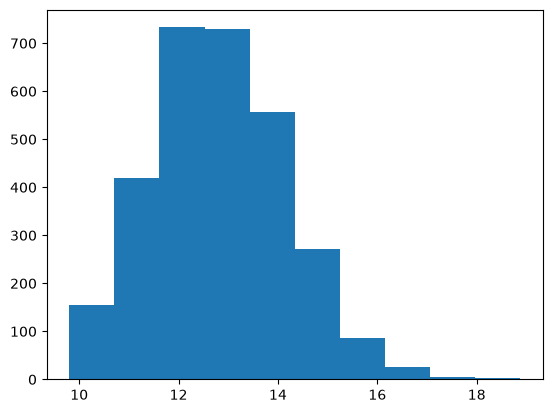

In [28]:
plt.hist(soupcon['Curricular units 1st sem (grade)'])

In [29]:
soupcon['Target'].value_counts()/soupcon.shape[0]

Target
0    0.714717
1    0.285283
Name: count, dtype: float64

In [30]:
x=np.arange(8,21,2)

for i in range(len(x)-1):
    temp=soupcon[(soupcon["Curricular units 1st sem (grade)"]>=x[i]) & (soupcon["Curricular units 1st sem (grade)"]<x[i+1])]
    print((x[i],x[i+1]))
    print(temp['Target'].value_counts()/temp.shape[0])
    print(temp.shape[0])

temp=soupcon[(soupcon["Curricular units 1st sem (grade)"]>=14) & (soupcon["Curricular units 1st sem (grade)"]<20)]
print((x[i],x[i+1]))
print(temp['Target'].value_counts()/temp.shape[0])
print(temp.shape[0])

(np.int64(8), np.int64(10))
Target
1    1.0
Name: count, dtype: float64
1
(np.int64(10), np.int64(12))
Target
1    0.501911
0    0.498089
Name: count, dtype: float64
785
(np.int64(12), np.int64(14))
Target
0    0.765217
1    0.234783
Name: count, dtype: float64
1610
(np.int64(14), np.int64(16))
Target
0    0.882463
1    0.117537
Name: count, dtype: float64
536
(np.int64(16), np.int64(18))
Target
0    0.729167
1    0.270833
Name: count, dtype: float64
48
(np.int64(18), np.int64(20))
Target
1    0.666667
0    0.333333
Name: count, dtype: float64
3
(np.int64(18), np.int64(20))
Target
0    0.867121
1    0.132879
Name: count, dtype: float64
587


In [31]:
import numpy as np
n = 52
p = 0.673  # Graduate
marge = 1.96 * np.sqrt(p*(1-p)/n)
print(f"{p*100:.0f}% ± {marge*100:.0f}%")

67% ± 13%


conclusion de cette analyse : les etudiants qui ont note_semestre1=0 sont divisés en trois groupes\

1er groupe: matiere_inscrit=0 et n_evaluation=0(47% dropout 41% graduate et 15% enroll) pour faire une conclusion concernant ce groupe on le fera dans les prochains analyses

2eme groupe: matiere_inscrit>0 et n_evaluation=0(dropout 100% ) hypothèse le plus plausible ils ont abandonné avant l'examen

3eme groupe: nb_matiere>0 et n_evaluation>0 (dropout 87%  11% graduate et 0.5% enroll) a verifier car c'est un peu bizarre de ne pas abandonner dans ce cas de figure et de reussir on verifiera dans les prochains analyses


In [32]:
groupe1=data.loc[data['Curricular units 1st sem (grade)']<3,:]
groupe1=groupe1.loc[(groupe1["Curricular units 1st sem (enrolled)"]==0) & (groupe1["Curricular units 1st sem (evaluations)"]==0)]
groupe1

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.0,0,10.8,1.4,1.74,1
20,1,1,3,171,1,1,122.0,1,1,1,...,0,0,0,0,0.0,0,11.1,0.6,2.02,0
66,1,1,3,171,1,1,139.0,1,19,19,...,0,0,0,0,0.0,0,10.8,1.4,1.74,0
72,1,1,1,171,1,1,141.0,1,19,19,...,0,0,0,0,0.0,0,15.5,2.8,-4.06,1
101,1,1,4,171,1,1,133.1,1,1,1,...,0,0,0,0,0.0,0,16.2,0.3,-0.92,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4308,1,44,1,171,1,39,110.0,1,1,1,...,0,0,0,0,0.0,0,12.4,0.5,1.79,1
4331,1,17,1,171,1,1,145.0,1,37,19,...,0,0,0,0,0.0,0,11.1,0.6,2.02,1
4353,1,1,1,171,1,1,141.0,1,3,1,...,0,0,0,0,0.0,0,12.4,0.5,1.79,0
4365,1,1,2,171,1,1,117.0,1,38,38,...,0,0,0,0,0.0,0,7.6,2.6,0.32,0


In [33]:
groupe1['Course'].value_counts()

Course
171    152
Name: count, dtype: int64

In [34]:
groupe1[['Curricular units 1st sem (approved)',
    'Curricular units 1st sem (credited)']].describe()

,Curricular units 1st sem (approved),Curricular units 1st sem (credited)
count,152.0,152.0
mean,0.0,0.0
std,0.0,0.0
min,0.0,0.0
25%,0.0,0.0
50%,0.0,0.0
75%,0.0,0.0
max,0.0,0.0


In [35]:
groupe2=data.loc[data['Curricular units 1st sem (grade)']<3,:]
groupe2=groupe2.loc[(groupe2["Curricular units 1st sem (enrolled)"]>0) & (groupe2["Curricular units 1st sem (evaluations)"]==0)]
groupe2

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.0,0,10.8,1.4,1.74,1
36,1,39,1,9119,1,10,133.1,1,34,37,...,0,5,0,0,0.0,0,7.6,2.6,0.32,1
44,1,39,1,9991,0,1,133.1,1,37,37,...,0,5,0,0,0.0,0,16.2,0.3,-0.92,1
102,2,39,1,8014,0,1,130.0,1,37,37,...,0,6,0,0,0.0,0,9.4,-0.8,-3.12,1
104,1,18,1,9853,1,1,123.0,1,19,19,...,0,6,0,0,0.0,0,11.1,0.6,2.02,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4145,1,1,1,9238,1,1,133.1,1,19,1,...,0,6,0,0,0.0,0,15.5,2.8,-4.06,1
4181,1,43,1,9853,1,1,110.0,1,37,37,...,0,5,10,0,0.0,0,10.8,1.4,1.74,1
4327,2,39,1,9147,1,12,133.1,1,37,37,...,0,5,0,0,0.0,0,9.4,-0.8,-3.12,1
4330,1,1,4,9238,1,1,133.1,1,1,37,...,0,6,0,0,0.0,0,12.7,3.7,-1.70,1


In [36]:
data['Course'].value_counts()

Course
9500    666
9238    313
9773    297
9147    272
9085    262
9670    220
9991    214
9254    211
8014    194
9070    184
171     178
9003    173
9853    142
9130    120
9119    106
9556     69
33        9
Name: count, dtype: int64

decision prise: creation de trois features:
groupe1: missing_data
groupe2: aggagement
groupe3: low_performance

In [37]:
no_academic_activity= (data['Curricular units 1st sem (grade)']==0) & (data['Curricular units 1st sem (evaluations)']==0) & (data['Curricular units 1st sem (enrolled)']==0)
data['no_academic_activity']=no_academic_activity.astype(int)

In [38]:
pd.crosstab(
    data['no_academic_activity'],
    data['Target'],
    normalize='index'
) * 100

Target,0,1
no_academic_activity,,
0,61.357102,38.642898
1,49.342105,50.657895


In [39]:
no_assessment_taken=(data['Curricular units 1st sem (grade)']==0) & (data['Curricular units 1st sem (evaluations)']==0) & (data['Curricular units 1st sem (enrolled)']>0)
data['no_assessment_taken']=no_assessment_taken.astype(int)


In [40]:
pd.crosstab(
    data['no_assessment_taken'],
    data['Target'],
    normalize='index'
) * 100

Target,0,1
no_assessment_taken,,
0,63.825484,36.174516
1,0.000000,100.000000


In [41]:
low_performance=(data['Curricular units 1st sem (grade)']==0) & (data['Curricular units 1st sem (evaluations)']>0) & (data['Curricular units 1st sem (enrolled)']>0)
data['low_performance']=low_performance.astype(int)

In [42]:
pd.crosstab(
    data['no_assessment_taken'],
    data['Target'],
    normalize='index'
)*100

Target,0,1
no_assessment_taken,,
0,63.825484,36.174516
1,0.000000,100.000000


(array([ 802.,    0.,    0.,    0.,    0.,  284., 1214., 1097.,  222.,
          11.]),
 array([ 0.        ,  1.85714286,  3.71428571,  5.57142857,  7.42857143,
         9.28571429, 11.14285714, 13.        , 14.85714286, 16.71428571,
        18.57142857]),
 <BarContainer object of 10 artists>)

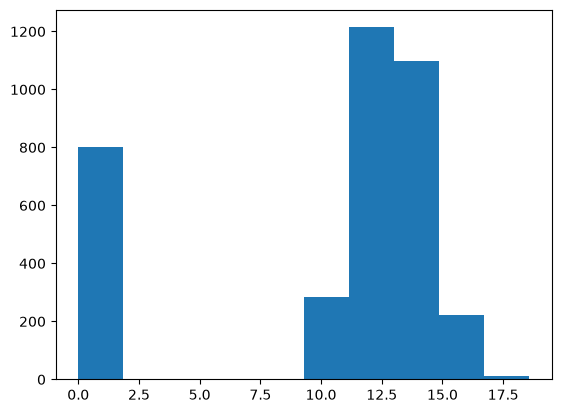

In [43]:
plt.hist(data['Curricular units 2nd sem (grade)'])

In [44]:
null_Second_grade=data.loc[data['Curricular units 2nd sem (grade)']==0,:]

null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']==0,:].shape[0]/null_Second_grade.shape[0]

0.7743142144638404

In [45]:
null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']==0,:].shape[0]/data.loc[data['Curricular units 1st sem (grade)']==0,:].shape[0]

0.9598145285935085

In [46]:
null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']!=0,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance
15,1,1,1,9773,1,1,127.0,1,19,37,...,0,0.0,0,15.5,2.8,-4.06,1,0,0,0
40,1,1,5,9773,1,1,126.0,1,3,3,...,0,0.0,0,12.7,3.7,-1.70,1,0,0,0
92,1,15,1,9130,1,1,133.1,41,1,1,...,0,0.0,0,8.9,1.4,3.51,1,0,0,0
93,2,39,1,9853,1,10,133.1,1,37,34,...,0,0.0,1,7.6,2.6,0.32,1,0,0,0
99,1,1,4,9500,1,1,115.0,1,3,3,...,0,0.0,0,13.9,-0.3,0.79,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4323,1,39,1,9991,0,19,133.1,1,37,37,...,0,0.0,0,12.4,0.5,1.79,1,0,0,0
4346,1,17,2,9254,1,1,107.0,1,12,19,...,0,0.0,0,10.8,1.4,1.74,1,0,0,0
4356,1,39,1,9085,1,19,133.1,1,37,37,...,0,0.0,0,11.1,0.6,2.02,1,0,0,0
4363,1,17,3,9853,1,1,133.1,1,34,34,...,0,0.0,0,7.6,2.6,0.32,1,0,0,0


In [47]:
null_Second_grade.loc[null_Second_grade['Curricular units 1st sem (grade)']!=0,'Target'].value_counts()

Target
1    181
Name: count, dtype: int64

In [48]:
data['grade2_echec']=(data['Curricular units 2nd sem (grade)']==0) & (data['Curricular units 1st sem (grade)']!=0)
data['grade2_echec']=data['grade2_echec'].astype(int)


In [49]:
pd.crosstab(
    data['grade2_echec'],
    data['Target'],
    normalize='index'
)*100

Target,0,1
grade2_echec,,
0,64.04755,35.95245
1,0.00000,100.00000


In [50]:
x = np.arange(8, 21, 2)  # [8, 10, 12, 14, 16, 18, 20]

for i in range(len(x) - 1):
    temp = data[
        (data["Curricular units 2nd sem (grade)"] >= x[i]) &
        (data["Curricular units 2nd sem (grade)"] < x[i+1])
    ]
    print((x[i], x[i+1]))
    print(temp['Target'].value_counts() / temp.shape[0])
    print(temp.shape[0])

# Intervalle fusionné : 14 à 20 (regroupe les deux derniers intervalles)
temp =data[
    (data["Curricular units 2nd sem (grade)"] >= 14) &
    (data["Curricular units 2nd sem (grade)"] < 20)
]
print((14, 20))  # ← corrigé : reflète l'intervalle réellement utilisé
print(temp['Target'].value_counts() / temp.shape[0])
print(temp.shape[0])

(np.int64(8), np.int64(10))
Series([], Name: count, dtype: float64)
0
(np.int64(10), np.int64(12))
Target
0    0.522284
1    0.477716
Name: count, dtype: float64
718
(np.int64(12), np.int64(14))
Target
0    0.810333
1    0.189667
Name: count, dtype: float64
1471
(np.int64(14), np.int64(16))
Target
0    0.894737
1    0.105263
Name: count, dtype: float64
589
(np.int64(16), np.int64(18))
Target
0    0.795918
1    0.204082
Name: count, dtype: float64
49
(np.int64(18), np.int64(20))
Target
0    1.0
Name: count, dtype: float64
1
(14, 20)
Target
0    0.887324
1    0.112676
Name: count, dtype: float64
639


(array([ 197.,  389.,  937., 1037.,  580.,  267.,  157.,   48.,   13.,
           5.]),
 array([ 95. , 104.5, 114. , 123.5, 133. , 142.5, 152. , 161.5, 171. ,
        180.5, 190. ]),
 <BarContainer object of 10 artists>)

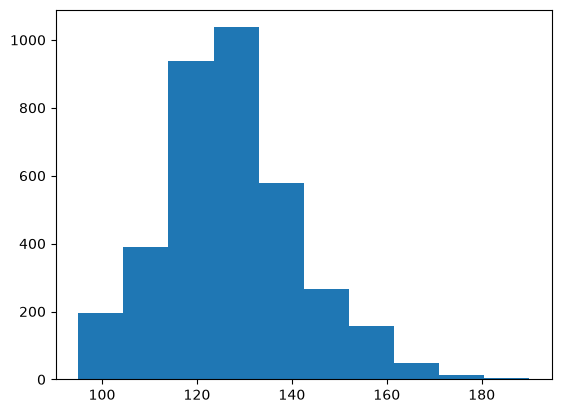

In [51]:
plt.hist(data['Admission grade'])

In [52]:
data.loc[data['Admission grade']<100,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance,grade2_echec
228,1,39,2,9670,1,1,140.0,1,34,34,...,0.000000,0,7.6,2.6,0.32,1,0,0,1,0
255,2,39,1,9556,1,19,133.1,1,38,37,...,0.000000,0,8.9,1.4,3.51,1,0,0,0,1
399,1,17,1,9147,1,1,96.0,1,38,37,...,0.000000,3,16.2,0.3,-0.92,1,0,0,0,1
417,1,1,1,9853,1,1,133.1,1,19,19,...,11.000000,0,12.7,3.7,-1.70,1,0,0,0,0
554,1,17,2,9147,1,1,133.1,1,1,1,...,0.000000,0,11.1,0.6,2.02,1,0,0,1,0
709,1,39,1,8014,0,1,133.1,1,37,11,...,0.000000,0,12.4,0.5,1.79,1,0,0,1,0
867,1,39,1,9119,1,19,133.1,1,37,38,...,0.000000,0,12.4,0.5,1.79,1,0,0,1,0
921,1,39,1,8014,0,1,133.1,1,37,37,...,11.500000,0,10.8,1.4,1.74,0,0,0,0,0
1163,4,39,1,8014,0,1,160.0,1,37,37,...,11.333333,0,15.5,2.8,-4.06,0,0,0,0,0
1239,1,1,1,9670,1,1,133.1,1,3,1,...,0.000000,0,15.5,2.8,-4.06,1,0,0,1,0


(array([  76.,  162.,  589.,  838., 1290.,  417.,  179.,   56.,   19.,
           4.]),
 array([ 95. , 104.5, 114. , 123.5, 133. , 142.5, 152. , 161.5, 171. ,
        180.5, 190. ]),
 <BarContainer object of 10 artists>)

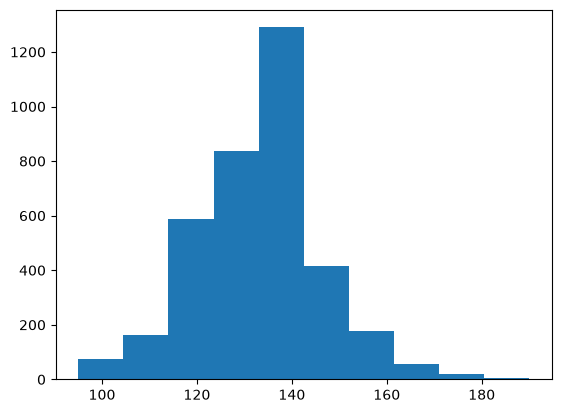

In [53]:
plt.hist(data['Previous qualification (grade)'])

In [54]:
credits_s1=data.loc[data['Curricular units 1st sem (credited)']>0,:]
credits_s1.shape[0]/data.shape[0]

0.1322314049586777

In [55]:
data.loc[data['Curricular units 1st sem (credited)']==20,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance,grade2_echec
2863,1,43,1,9853,1,1,140.0,1,37,37,...,12.105263,0,12.4,0.5,1.79,0,0,0,0,0
3961,1,42,1,9500,1,1,168.0,1,37,1,...,15.023529,0,15.5,2.8,-4.06,0,0,0,0,0


In [56]:
data['Curricular units 1st sem (credited)'].value_counts()

Curricular units 1st sem (credited)
0     3150
2       71
1       67
3       57
6       43
4       43
7       31
5       31
8       27
9       24
11      16
14      14
10      14
13      12
12      11
15       5
18       4
16       3
17       3
19       2
20       2
Name: count, dtype: int64

In [57]:
data.loc[data['Curricular units 1st sem (credited)']!=0,'Target'].value_counts()

Target
0    301
1    179
Name: count, dtype: int64

In [58]:
data['Curricular units 2nd sem (without evaluations)'].value_counts()

Curricular units 2nd sem (without evaluations)
0     3416
1      107
2       35
3       23
5       16
4       16
6        7
7        4
8        4
12       2
Name: count, dtype: int64

In [59]:
data.loc[data['Curricular units 2nd sem (without evaluations)']!=0,'Target'].value_counts()

Target
1    123
0     91
Name: count, dtype: int64

In [60]:
data.loc[data['Curricular units 1st sem (evaluations)']==45,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance,grade2_echec
747,1,43,1,9085,1,1,110.0,25,38,38,...,11.428571,6,15.5,2.8,-4.06,0,0,0,0,0
894,1,42,1,9085,1,39,150.0,1,1,1,...,12.461538,5,15.5,2.8,-4.06,0,0,0,0,0


In [61]:
data.loc[data['Age at enrollment']==70,:]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,no_academic_activity,no_assessment_taken,low_performance,grade2_echec
689,4,39,2,9147,1,19,133.1,1,37,37,...,0.0,0,10.8,1.4,1.74,1,0,0,1,0


In [62]:
categorical=['Marital status','Application mode','Application order','Course','Daytime/evening attendance','Nacionality',"Previous qualification","Mother's qualification","Father's qualification","Mother's occupation","Father's occupation","Displaced","Educational special needs","Debtor","Tuition fees up to date","Gender","Scholarship holder","International","Target"]
data[categorical]

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Nacionality,Previous qualification,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,International,Target
0,1,17,5,171,1,1,1,19,12,5,9,1,0,0,1,1,0,0,1
1,1,15,1,9254,1,1,1,1,3,3,3,1,0,0,0,1,0,0,0
2,1,1,5,9070,1,1,1,37,37,9,9,1,0,0,0,1,0,0,1
3,1,17,2,9773,1,1,1,38,37,5,3,1,0,0,1,0,0,0,0
4,2,39,1,8014,0,1,1,37,38,9,9,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,1,1,1,5,4,0,0,0,1,1,0,0,0
4420,1,1,2,9773,1,105,1,1,1,9,9,1,0,1,0,0,0,1,1
4421,1,1,1,9500,1,1,1,37,37,9,9,1,0,0,1,0,1,0,1
4422,1,1,1,9147,1,1,1,37,37,7,4,1,0,0,1,0,1,0,0


In [63]:
for col in categorical:
    print(data[col].value_counts())

Marital status
1    3199
2     327
4      75
5      22
6       5
3       2
Name: count, dtype: int64
Application mode
1     1408
17     713
39     664
43     237
44     157
7      132
18     108
42      66
51      46
16      30
53      25
15      20
10      10
5        8
2        3
57       1
26       1
27       1
Name: count, dtype: int64
Application order
1    2461
2     451
3     249
4     218
5     129
6     121
0       1
Name: count, dtype: int64
Course
9500    666
9238    313
9773    297
9147    272
9085    262
9670    220
9991    214
9254    211
8014    194
9070    184
171     178
9003    173
9853    142
9130    120
9119    106
9556     69
33        9
Name: count, dtype: int64
Daytime/evening attendance
1    3222
0     408
Name: count, dtype: int64
Nacionality
1      3544
41       32
22       12
26        9
6         8
24        5
11        3
103       3
2         2
100       2
101       2
62        1
13        1
25        1
109       1
21        1
14        1
17        1
105   

In [64]:
for col in categorical:
    temp=pd.crosstab(
    data[col],
    data['Target'],
    normalize='index'
)*100
    temp['freq']=[(data.loc[data[col]==x].shape[0]/data.shape[0])*100 for x in temp.index]
    temp['n']=[data.loc[data[col]==x].shape[0] for x in temp.index]
    print(temp)

Target                  0          1       freq     n
Marital status                                       
1               62.988434  37.011566  88.126722  3199
2               45.259939  54.740061   9.008264   327
3               50.000000  50.000000   0.055096     2
4               44.000000  56.000000   2.066116    75
5               50.000000  50.000000   0.606061    22
6               20.000000  80.000000   0.137741     5
Target                     0           1       freq     n
Application mode                                         
1                  75.497159   24.502841  38.787879  1408
2                  33.333333   66.666667   0.082645     3
5                  75.000000   25.000000   0.220386     8
7                  35.606061   64.393939   3.636364   132
10                 70.000000   30.000000   0.275482    10
15                 75.000000   25.000000   0.550964    20
16                 83.333333   16.666667   0.826446    30
17                 64.095372   35.904628  19.6

pour le statut matrimoniale les celibataires dominent fortement avec 88% de frequence, pour les mariés(2) on constate une augmentation du taux de dropout , la meme chose est constaté pour les veufs.

 le taux de dropout globale est 32% donc la variable semble apporter de l'information.

 mais parcontre pour les autres categories il ya peu de categorie pour conclure rigoureusement d'une eventuelle difference. 

 les categories rares pourraient etre regroupées si necessaaire.

La variable Application mode présente de nombreuses modalités, dont certaines sont très peu représentées. Les principales modalités montrent des taux de dropout très différents (par exemple, environ 20 % pour le mode 1 contre plus de 55 % pour le mode 39), ce qui suggère que cette variable est potentiellement informative. En revanche, les modalités très rares doivent être interprétées avec prudence et pourront être regroupées lors du prétraitement si nécessaire.

application order après analyse a deux categories rares qui sont 0 et 9 et les autres sont a peu près interpretables.
mais les autres presentent des pourcentages différentes donc la variable semble apporter de l'information.

pour la filière(course) la seule categorie non interpretatble est la categorie est 33 qui a très peu de categorie. 
meme si il ya beaucoup de categorie on la regrouperait pas tout de suite on verra lors du test du modèle si un regroupement par domaine ameliore quelque chose sinon les categories restent telle quelles.

Les étudiants inscrits en cours de jour et ceux en cours du soir présentent des taux de dropout différents(peut etre les etudiants qui etudie le soir ont moins de temps que ceux qui assistent en journée)

les categories de la variable nationalité sont tres rares sauf la categorie 1 donc elle seule est interpretable et les autres sont peu interpretables donc on decidera de les regrouper en une categorie autres et tester l'influence sur le modèle. 


La variable Mother’s qualification présente une forte hétérogénéité des modalités, avec quelques catégories principales concentrant la majorité des observations et de nombreuses catégories très rares.
Plusieurs modalités ont des effectifs très faibles (n ≤ 5), ce qui rend leurs proportions de dropout instables et non fiables.
Les catégories rares peuvent introduire du bruit statistique et favoriser des comportements de surapprentissage dans les modèles.
La variable possède une structure hiérarchique liée au niveau d’éducation, ce qui rend pertinent un regroupement par niveaux (enseignement supérieur, secondaire, éducation de base, faible niveau, inconnu).
Certaines catégories spécifiques (ex : fréquentation du supérieur sans diplôme) peuvent être regroupées ou traitées séparément selon leur effectif et leur interprétation métier.
Le regroupement doit être fait selon une logique métier cohérente, et non uniquement sur la base des fréquences observées.

Les variables Father’s qualification et Mother’s qualification présentent une structure similaire et ont été traitées avec le même schéma de regroupement basé sur les niveaux d’éducation afin de garantir la cohérence du feature engineering.

Bien que la variable Profession contienne déjà une hiérarchie entre classes socio-professionnelles et sous-catégories détaillées, les niveaux détaillés présentent une forte rareté statistique. Par conséquent, les sous-catégories sont agrégées au niveau macro afin de réduire la cardinalité et d’améliorer la robustesse des modèles, tout en conservant la structure socio-professionnelle existante.

La variable Previous qualification est regroupée en grandes familles éducatives afin de réduire la cardinalité et stabiliser les distributions. Les modalités rares sont fusionnées, tandis que certaines catégories techniques sont conservées séparément lorsqu’elles présentent un comportement distinct vis-à-vis de la variable cible.

a variable Displaced montre une différence modérée dans la distribution de la cible entre les deux groupes.

Les étudiants déplacés (1) présentent une proportion légèrement plus élevée de la classe “succès/inscription”.
Les non déplacés (0) sont légèrement plus concentrés dans les autres classes.

La grande majorité des étudiants ne présentent pas de besoins éducatifs spéciaux (≈ 99%).
Les étudiants concernés (1) sont très minoritaires.
Variable fortement déséquilibrée.
Peu de signal exploitable seul, mais peut être utile en interaction avec d’autres variables.

La variable Debtor présente un effet très marqué :

Les étudiants endettés (1) ont une proportion beaucoup plus élevée de la classe défavorable (dropout).
Les non-endettés (0) sont davantage associés à des résultats positifs.

Variable fortement discriminante et potentiellement très informative pour la prédiction

Les étudiants ayant payé leurs frais (1) sont majoritairement associés à la réussite ou la continuité.
Les étudiants en retard de paiement (0) sont fortement associés au dropout.

On observe une différence de distribution de la cible selon le genre :

Les hommes et les femmes présentent des profils légèrement différents vis-à-vis des classes cibles.
Effet modéré mais non négligeable.

La variable montre un effet très fort :

Les étudiants boursiers (1) sont beaucoup plus concentrés dans une catégorie favorable.
Les non-boursiers (0) présentent une distribution plus défavorable.

In [65]:
data.loc[data['Nacionality']!=1,'International'].value_counts()

International
1    86
Name: count, dtype: int64

a variable Nationality a été initialement envisagée pour être regroupée en deux modalités (Portugal vs autres pays), afin de réduire la cardinalité et le nombre de catégories rares. Cette transformation devient équivalente à la variable International, qui encode déjà cette information de manière binaire. Par conséquent, ces deux variables sont redondantes, et la variable International est conservée pour sa simplicité et sa robustesse.

In [66]:
data['Marital_status_grouped'] = data['Marital status'].replace({
    1: 'Single',
    2: 'Married',
    3: 'Other',
    4: 'divorced',
    5: 'Other',
    6: 'Other'
})

data[['Marital status','Marital_status_grouped']]

,Marital status,Marital_status_grouped
0,1,Single
1,1,Single
2,1,Single
3,1,Single
4,2,Married
...,...,...
4419,1,Single
4420,1,Single
4421,1,Single
4422,1,Single


In [67]:
frequent_modes = [1, 7, 17, 18, 39, 42, 43, 44]

data['Application_mode_grouped'] = data['Application mode'].apply(
    lambda x: x if x in frequent_modes else 'Other'
)

data['Application_mode_grouped']

0          17
1       Other
2           1
3          17
4          39
        ...  
4419        1
4420        1
4421        1
4422        1
4423    Other
Name: Application_mode_grouped, Length: 3630, dtype: object

In [68]:
mapping = {
    1: "1ère phase - contingent général",
    7: "Détenteurs d’autres cursus supérieurs",
    17: "2e phase - contingent général",
    18: "3e phase - contingent général",
    39: "Plus de 23 ans",
    42: "Transfert",
    43: "Changement de programme",
    44: "Diplôme de spécialisation technologique"
}

data['Application_mode_grouped'] = data['Application_mode_grouped'].replace(mapping)

data['Application_mode_grouped']


0         2e phase - contingent général
1                                 Other
2       1ère phase - contingent général
3         2e phase - contingent général
4                        Plus de 23 ans
                     ...               
4419    1ère phase - contingent général
4420    1ère phase - contingent général
4421    1ère phase - contingent général
4422    1ère phase - contingent général
4423                              Other
Name: Application_mode_grouped, Length: 3630, dtype: object

In [69]:
mother_qualification_grouped = {
    # Enseignement supérieur
    2: "Enseignement supérieur",
    3: "Enseignement supérieur",
    4: "Enseignement supérieur",
    5: "Enseignement supérieur",
    6: "Enseignement supérieur",
    40: "Enseignement supérieur",
    41: "Enseignement supérieur",
    42: "Enseignement supérieur",
    43: "Enseignement supérieur",
    44: "Enseignement supérieur",

  
    1: "Enseignement secondaire",
    9: "Enseignement secondaire",
    10: "Enseignement secondaire",
    11: "Enseignement secondaire",
    12: "Enseignement secondaire",
    14: "Enseignement secondaire",
    27: "Enseignement secondaire",

   
    19: "Éducation de base",
    26: "Éducation de base",
    29: "Éducation de base",
    30: "Éducation de base",
    37: "Éducation de base",
    38: "Éducation de base",


    18: "Formation professionnelle / technique",
    22: "Formation professionnelle / technique",
    39: "Formation professionnelle / technique",

    35: "Faible niveau d'instruction",
    36: "Faible niveau d'instruction",

    34: "Inconnu"
}

data["Mother's_qualification_grouped"] = data["Mother's qualification"].replace(
    mother_qualification_grouped
)

data[["Mother's qualification","Mother's_qualification_grouped"]]

,Mother's qualification,Mother's_qualification_grouped
0,19,Éducation de base
1,1,Enseignement secondaire
2,37,Éducation de base
3,38,Éducation de base
4,37,Éducation de base
...,...,...
4419,1,Enseignement secondaire
4420,1,Enseignement secondaire
4421,37,Éducation de base
4422,37,Éducation de base


In [70]:
print(data["Mother's_qualification_grouped"].unique())

['Éducation de base' 'Enseignement secondaire' 'Enseignement supérieur'
 'Inconnu' 'Formation professionnelle / technique'
 "Faible niveau d'instruction"]


In [71]:
father_qualification_grouped = {
    
    2: "Enseignement supérieur",
    3: "Enseignement supérieur",
    4: "Enseignement supérieur",
    5: "Enseignement supérieur",
    6: "Enseignement supérieur",
    40: "Enseignement supérieur",
    41: "Enseignement supérieur",
    42: "Enseignement supérieur",
    43: "Enseignement supérieur",
    44: "Enseignement supérieur",

  
    1: "Enseignement secondaire",
    9: "Enseignement secondaire",
    10: "Enseignement secondaire",
    11: "Enseignement secondaire",
    12: "Enseignement secondaire",
    13:"Enseignement secondaire",
    14: "Enseignement secondaire",
    27: "Enseignement secondaire",

   
    19: "Éducation de base",
    26: "Éducation de base",
    29: "Éducation de base",
    30: "Éducation de base",
    37: "Éducation de base",
    38: "Éducation de base",


    18: "Formation professionnelle / technique",
    20:"Formation professionnelle / technique",
    22: "Formation professionnelle / technique",
    25:"Formation professionnelle / technique",
    31:"Formation professionnelle / technique",
    33:"Formation professionnelle / technique",
    39: "Formation professionnelle / technique",

    35: "Faible niveau d'instruction",
    36: "Faible niveau d'instruction",

    34: "Inconnu"
}


In [72]:
data["Father's_qualification_grouped"]=data["Father's qualification"].replace(father_qualification_grouped )

In [73]:
data["Father's_qualification_grouped"].unique()

array(['Enseignement secondaire', 'Enseignement supérieur',
       'Éducation de base', 'Inconnu',
       'Formation professionnelle / technique',
       "Faible niveau d'instruction"], dtype=object)

In [74]:
mother_profession_grouped = {
    # Macro déjà présentes
    0: "Étudiant",
    1: "Dirigeants / cadres supérieurs",
    2: "Spécialistes",
    3: "Techniciens / professions intermédiaires",
    4: "Personnel administratif",
    5: "Services / vente / sécurité",
    6: "Agriculture / pêche / sylviculture",
    7: "Industrie / construction / artisans",
    8: "Opérateurs de machines",
    9: "Travailleurs non qualifiés",
    10: "Forces armées",
    90: "Autres situations",
    99: "Données manquantes",

    # Spécialistes
    122: "Spécialistes",
    123: "Spécialistes",
    125: "Spécialistes",

    # Professions intermédiaires
    131: "Techniciens / professions intermédiaires",
    132: "Techniciens / professions intermédiaires",
    134: "Techniciens / professions intermédiaires",

    # Administration
    141: "Personnel administratif",
    143: "Personnel administratif",
    144: "Personnel administratif",

    # Services
    151: "Services / vente / sécurité",
    152: "Services / vente / sécurité",
    153: "Services / vente / sécurité",

    # Industrie / artisans
    171: "Industrie / construction / artisans",
    173: "Industrie / construction / artisans",
    175: "Industrie / construction / artisans",

    # Non qualifiés
    191: "Travailleurs non qualifiés",
    192: "Travailleurs non qualifiés",
    193: "Travailleurs non qualifiés",
    194: "Travailleurs non qualifiés"
}

data["Mother's_occupation_grouped"] = (
    data["Mother's occupation"].replace(mother_profession_grouped)
)

data[["Mother's_occupation_grouped","Mother's occupation"]]

,Mother's_occupation_grouped,Mother's occupation
0,Services / vente / sécurité,5
1,Techniciens / professions intermédiaires,3
2,Travailleurs non qualifiés,9
3,Services / vente / sécurité,5
4,Travailleurs non qualifiés,9
...,...,...
4419,Services / vente / sécurité,5
4420,Travailleurs non qualifiés,9
4421,Travailleurs non qualifiés,9
4422,Industrie / construction / artisans,7


In [75]:
data["Mother's_occupation_grouped"].unique()

array(['Services / vente / sécurité',
       'Techniciens / professions intermédiaires',
       'Travailleurs non qualifiés',
       'Industrie / construction / artisans', 'Personnel administratif',
       'Dirigeants / cadres supérieurs', 'Spécialistes', 'Étudiant',
       'Agriculture / pêche / sylviculture', 'Autres situations',
       'Opérateurs de machines', 'Données manquantes', 'Forces armées'],
      dtype=object)

In [76]:
Father_profession_grouped = {

    # Étudiant
    0: "Étudiant",

    # Dirigeants / cadres supérieurs
    1: "Dirigeants / cadres supérieurs",
    112: "Dirigeants / cadres supérieurs",
    114: "Dirigeants / cadres supérieurs",

    # Spécialistes
    2: "Spécialistes",
    121: "Spécialistes",
    122: "Spécialistes",
    123: "Spécialistes",
    124: "Spécialistes",

    # Techniciens / professions intermédiaires
    3: "Techniciens / professions intermédiaires",
    131: "Techniciens / professions intermédiaires",
    132: "Techniciens / professions intermédiaires",
    134: "Techniciens / professions intermédiaires",
    135: "Techniciens / professions intermédiaires",

    # Personnel administratif
    4: "Personnel administratif",
    141: "Personnel administratif",
    143: "Personnel administratif",
    144: "Personnel administratif",

    # Services / vente / sécurité
    5: "Services / vente / sécurité",
    151: "Services / vente / sécurité",
    152: "Services / vente / sécurité",
    153: "Services / vente / sécurité",
    154: "Services / vente / sécurité",

    # Agriculture / pêche / sylviculture
    6: "Agriculture / pêche / sylviculture",
    161: "Agriculture / pêche / sylviculture",
    163: "Agriculture / pêche / sylviculture",

    # Industrie / construction / artisans
    7: "Industrie / construction / artisans",
    171: "Industrie / construction / artisans",
    172: "Industrie / construction / artisans",
    174: "Industrie / construction / artisans",
    175: "Industrie / construction / artisans",

    # Opérateurs de machines
    8: "Opérateurs de machines",
    181: "Opérateurs de machines",
    182: "Opérateurs de machines",
    183: "Opérateurs de machines",

    # Travailleurs non qualifiés
    9: "Travailleurs non qualifiés",
    192: "Travailleurs non qualifiés",
    193: "Travailleurs non qualifiés",
    194: "Travailleurs non qualifiés",
    195: "Travailleurs non qualifiés",

    # Forces armées
    10: "Forces armées",
    101: "Forces armées",
    102: "Forces armées",
    103: "Forces armées",

    # Autres / manquants
    90: "Autres situations",
    99: "Données manquantes"
}

In [77]:
data["Father's_occupation_grouped"]= (
    data["Father's occupation"].replace(Father_profession_grouped)
)

data[["Father's_occupation_grouped","Father's occupation"]]

,Father's_occupation_grouped,Father's occupation
0,Travailleurs non qualifiés,9
1,Techniciens / professions intermédiaires,3
2,Travailleurs non qualifiés,9
3,Techniciens / professions intermédiaires,3
4,Travailleurs non qualifiés,9
...,...,...
4419,Personnel administratif,4
4420,Travailleurs non qualifiés,9
4421,Travailleurs non qualifiés,9
4422,Personnel administratif,4


In [78]:
data["Father's_occupation_grouped"].unique()

array(['Travailleurs non qualifiés',
       'Techniciens / professions intermédiaires',
       'Industrie / construction / artisans', 'Forces armées',
       'Services / vente / sécurité', 'Personnel administratif',
       'Opérateurs de machines', 'Dirigeants / cadres supérieurs',
       'Spécialistes', 'Agriculture / pêche / sylviculture', 'Étudiant',
       'Autres situations', 'Données manquantes'], dtype=object)

In [79]:
previous_qualification_grouped = {
    2: "Enseignement supérieur",
    3: "Enseignement supérieur",
    4: "Enseignement supérieur",
    5: "Enseignement supérieur",
    6: "Enseignement supérieur",
    40: "Enseignement supérieur",
    42: "Enseignement supérieur",
    43: "Enseignement supérieur",

  
    1: "Enseignement secondaire",
    9: "Enseignement secondaire",
    10: "Enseignement secondaire",
    12: "Enseignement secondaire",
    14: "Enseignement secondaire",
    15: "Enseignement secondaire",


    19: "Éducation de base",
    38: "Éducation de base",

    39: "Formation professionnelle / technique"
}

data["Previous_qualification_grouped"] = (
    data["Previous qualification"]
    .replace(previous_qualification_grouped)
)


data[["Previous_qualification_grouped","Previous qualification"]]

,Previous_qualification_grouped,Previous qualification
0,Enseignement secondaire,1
1,Enseignement secondaire,1
2,Enseignement secondaire,1
3,Enseignement secondaire,1
4,Enseignement secondaire,1
...,...,...
4419,Enseignement secondaire,1
4420,Enseignement secondaire,1
4421,Enseignement secondaire,1
4422,Enseignement secondaire,1


In [80]:

course_mapping = {
    33: "Technologies de production de biocarburants",
    171: "Animation et conception multimédia",
    8014: "Service social (présence en soirée)",
    9003: "Agronomie",
    9070: "Design de communication",
    9085: "Soins infirmiers vétérinaires",
    9119: "Génie informatique",
    9130: "Équiculture",
    9147: "Gestion",
    9238: "Service social",
    9254: "Tourisme",
    9500: "Soins infirmiers",
    9556: "Hygiène bucco-dentaire",
    9670: "Gestion de la publicité et du marketing",
    9773: "Journalisme et communication",
    9853: "Éducation de base",
    9991: "Gestion (présence du soir)"
}

data['Course']=data['Course'].replace(course_mapping)
data['Course']

0        Animation et conception multimédia
1                                  Tourisme
2                   Design de communication
3              Journalisme et communication
4       Service social (présence en soirée)
                       ...                 
4419           Journalisme et communication
4420           Journalisme et communication
4421                       Soins infirmiers
4422                                Gestion
4423           Journalisme et communication
Name: Course, Length: 3630, dtype: object

In [81]:
variable_a_encoder=["Displaced","Educational special needs","Debtor","Tuition fees up to date","Scholarship holder","International"]
for x in variable_a_encoder:
    data[x]=data[x].replace({1:"oui",0:"non"})

data['Daytime/evening attendance']=data['Daytime/evening attendance'].replace({1:"journée",0:"soirée"})
data['Gender']=data['Gender'].replace({1:"Homme",0:"Femme"})
variable_a_encoder.extend(['Daytime/evening attendance','Gender'])

data[variable_a_encoder]

,Displaced,Educational special needs,Debtor,Tuition fees up to date,Scholarship holder,International,Daytime/evening attendance,Gender
0,oui,non,non,oui,non,non,journée,Homme
1,oui,non,non,non,non,non,journée,Homme
2,oui,non,non,non,non,non,journée,Homme
3,oui,non,non,oui,non,non,journée,Femme
4,non,non,non,oui,non,non,soirée,Femme
...,...,...,...,...,...,...,...,...
4419,non,non,non,oui,non,non,journée,Homme
4420,oui,non,oui,non,non,oui,journée,Femme
4421,oui,non,non,oui,oui,non,journée,Femme
4422,oui,non,non,oui,oui,non,journée,Femme


### Sauvegarder les modifications apportées 

In [82]:
data.to_csv("../data/data_preprocessed.csv", index=False)